# Problem Statement
The objective of this analysis is to explore the Netflix titles dataset to understand the distribution of movies and TV shows, identify content trends over time, analyze the most contributing countries, and examine the most common genres available on the platform.

### About this Dataset:
Netflix is one of the most popular media and video streaming platforms. They have over 8000 movies or tv shows available on their platform, as of mid-2021, they have over 200M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

### Import necessary libraries and load the dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (5,5)

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Basic Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.shape

(8807, 12)

In [5]:
df.size

105684

Dataset contains 8,807 records (rows) and 12 features (columns)

Some of the columns like director, cast, country, date_added, rating and duration has missing values

These will be need to handle during data cleaning stage.

### Check for duplicates and drop the unwanted columns

In [6]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


No duplicate rows were found in the dataset

In [7]:
df.drop(columns = "show_id", inplace = True)

'show_id' is a unique identifier and does not contribute to the analysis,
so it is removed from the dataset.

### Check for any anomolies and treat if any

In [8]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print("---------------------------------------------------------------------")
    

type
2
['Movie' 'TV Show']
---------------------------------------------------------------------
title
8807
['Dick Johnson Is Dead' 'Blood & Water' 'Ganglands' ... 'Zombieland'
 'Zoom' 'Zubaan']
---------------------------------------------------------------------
director
4528
['Kirsten Johnson' nan 'Julien Leclercq' ... 'Majid Al Ansari'
 'Peter Hewitt' 'Mozez Singh']
---------------------------------------------------------------------
cast
7692
[nan
 'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng'
 'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera'
 ...
 'Jesse Eisenberg, Woody Harrelson, Emma Stone, Abigail Breslin, Amber Heard, B

No obvious anomalies were observed from the categorical values during initial inspection.

### Check data type and treat the misclassified columns

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   title         8807 non-null   object
 2   director      6173 non-null   object
 3   cast          7982 non-null   object
 4   country       7976 non-null   object
 5   date_added    8797 non-null   object
 6   release_year  8807 non-null   int64 
 7   rating        8803 non-null   object
 8   duration      8804 non-null   object
 9   listed_in     8807 non-null   object
 10  description   8807 non-null   object
dtypes: int64(1), object(10)
memory usage: 757.0+ KB


In [10]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format = "%B %d, %Y")

'date_added' is converted from object to datetime for time-based analysis

### Seperating Numerical and Categorical Columns

In [12]:
num = df.select_dtypes(include = np.number).columns.to_list()
num

['release_year']

In [13]:
cat = df.select_dtypes(include = object).columns.to_list()
cat

['type',
 'title',
 'director',
 'cast',
 'country',
 'rating',
 'duration',
 'listed_in',
 'description']

In [14]:
date = df.select_dtypes(include = "datetime").columns.to_list()
date

['date_added']

The dataset contains 1 numerical column, 9 categorical columns, and 1 datetime column

### Stats Summary

In [15]:
df[num].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Most Netflix content in the dataset was released after 2010,
since both the median (2017) and upper quartile (2019) fall in recent years.

In [16]:
df[cat].describe()

,type,title,director,cast,country,rating,duration,listed_in,description
count,8807,8807,6173,7982,7976,8803,8804,8807,8807
unique,2,8807,4528,7692,748,17,220,514,8775
top,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,6131,1,19,19,2818,3207,1793,362,4


• The dataset contains 8,807 Netflix titles released between 1925 and 2021.

• The median release year is 2017, indicating that most content is relatively recent.

• Each title appears only once in the dataset.

• Rajiv Chilaka is the most frequently listed director with 19 titles.

• The most common rating category is TV-MA.

• The most frequent duration value is "1 Season", suggesting many TV shows have a single season.

### Treat Missing Values

In [17]:
df.isna().sum()/ df.shape[0] * 100

type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [18]:
df.isna().sum().sum()/df.size * 100

4.445843698710736

In [19]:
df["director"] = df["director"].fillna("Unknown")

In [20]:
df["cast"] = df["cast"].fillna("Unknown")

In [21]:
df["country"] = df["country"].fillna(df["country"].mode()[0])

In [22]:
df.dropna(subset = ["date_added"], inplace = True) 

In [23]:
df["rating"].fillna(df["rating"].mode()[0], inplace = True)

In [24]:
df["duration"].fillna(df["duration"].mode()[0], inplace = True)

In [25]:
df.isna().sum().sum()

0

Although the overall missing values were only around 4%, some columns had significant missing values (e.g., director ~30%). 
Instead of dropping rows and losing valuable data, missing values in categorical columns were filled appropriately using 
'Unknown' or the most frequent value (mode). Rows with missing date_added were dropped since they were very few.

### Deep analysis

### Univariant Analysis

In [26]:
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

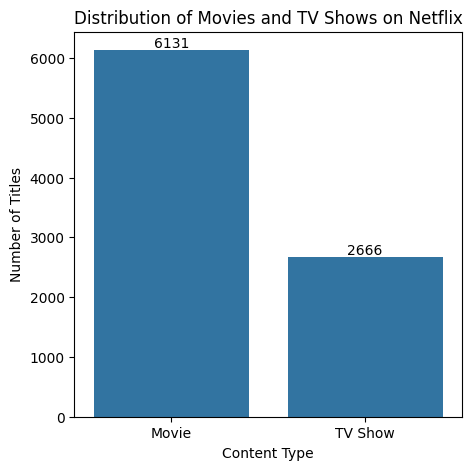

In [27]:
res = sns.countplot(x= "type", data = df)
for container in res.containers:
    res.bar_label(container)
plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

Movies dominate the Netflix catalog with 6,131 titles, which is more than double the number of TV shows (2,666).

In [28]:
df["country"].str.split(", ").explode().value_counts().head(10)

country
United States     4513
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

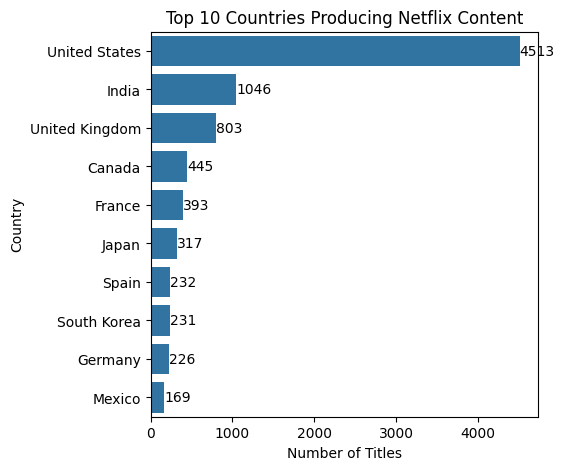

In [29]:
top_countries = df["country"].str.split(", ").explode().value_counts().head(10)

res = sns.barplot(x=top_countries.values, y=top_countries.index)
for container in res.containers:
    res.bar_label(container)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

The United States contributes the highest number of Netflix titles with 4513 entries,
significantly higher than any other country in the dataset.

In [30]:
df["release_year"].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

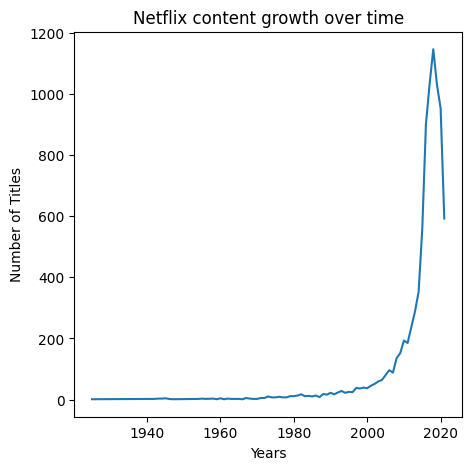

In [31]:
df["release_year"].value_counts().sort_index().plot()
plt.title("Netflix content growth over time")
plt.xlabel("Years")
plt.ylabel("Number of Titles")
plt.show()

Netflix content releases remained relatively low until the early 2000s.
However, there is a sharp increase after 2015, indicating Netflix's rapid expansion
and investment in acquiring and producing content during that period.

In [32]:
genres = df["listed_in"].str.split(", ").explode()

genres.value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

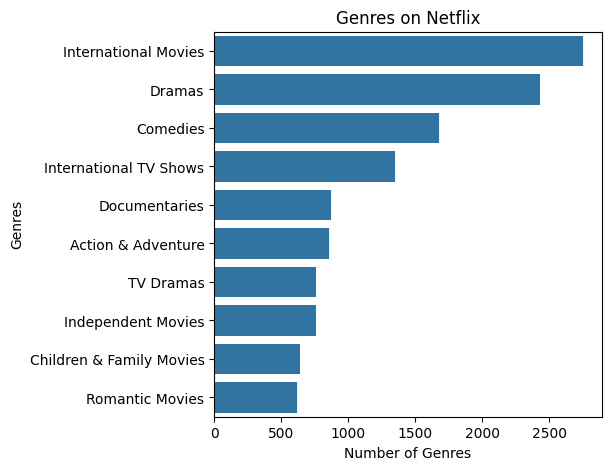

In [33]:
top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Genres on Netflix")
plt.xlabel("Number of Genres")
plt.ylabel("Genres")
plt.show()

International Movies is the most common genre on Netflix,
followed by Dramas and Comedies. This suggests that Netflix
offers a large amount of globally produced content, indicating
a strong focus on international audiences.

In [38]:
movies = df[df["type"] == "Movie"].copy()

In [39]:
movies["duration"].unique()

array(['90 min', '91 min', '125 min', '104 min', '127 min', '67 min',
       '94 min', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '110 min', '105 min', '96 min',
       '124 min', '116 min', '98 min', '23 min', '115 min', '122 min',
       '99 min', '88 min', '100 min', '102 min', '93 min', '95 min',
       '85 min', '83 min', '113 min', '13 min', '182 min', '48 min',
       '145 min', '87 min', '92 min', '80 min', '117 min', '128 min',
       '119 min', '143 min', '114 min', '118 min', '108 min', '63 min',
       '121 min', '142 min', '154 min', '120 min', '82 min', '109 min',
       '101 min', '86 min', '229 min', '76 min', '89 min', '156 min',
       '112 min', '107 min', '129 min', '135 min', '136 min', '165 min',
       '150 min', '133 min', '70 min', '84 min', '140 min', '78 min',
       '64 min', '59 min', '139 min', '69 min', '148 min', '189 min',
       '141 min', '130 min', '138 min', '81 min', '132 min', '123 min',
       '65

In [40]:
movies["duration"] = movies["duration"].str.extract(r"(\d+)")
movies["duration"] = movies["duration"].astype(int)

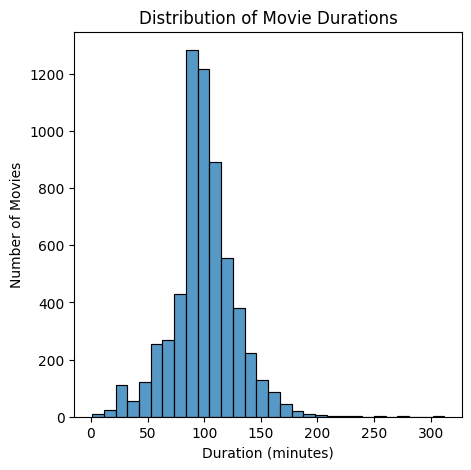

In [41]:
sns.histplot(movies["duration"], bins=30)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.show()

Most Netflix movies have durations between 80 and 120 minutes, indicating a preference for standard feature-length films.

In [42]:
df["rating"].value_counts().head(10)

rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

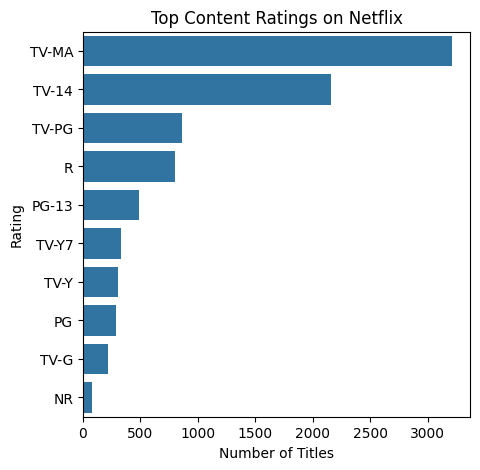

In [43]:
top_rating = df["rating"].value_counts().head(10)
sns.barplot(x=top_rating.values, y=top_rating.index)
plt.title("Top Content Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()

TV-MA is the most common rating on Netflix, indicating that a large portion of content is targeted toward mature audiences.

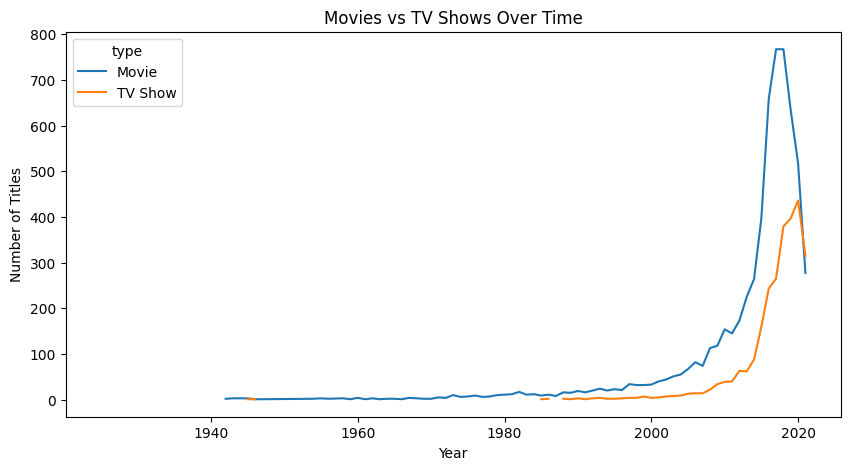

In [44]:
content_year = df.groupby(["release_year", "type"]).size().unstack()
content_year.plot(figsize=(10,5))
plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Both movies and TV shows have increased over time, but movies consistently dominate the platform.

In [45]:
df["director"].value_counts().head(10)

director
Unknown                   2624
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: int64

Certain directors appear multiple times, indicating repeated collaborations with Netflix.

In [46]:
pd.crosstab(df["type"], df["rating"])

rating,66 min,74 min,84 min,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,,,,
Movie,1,1,1,41,3,75,287,490,797,1427,126,2064,540,131,139,5,3
TV Show,0,0,0,0,0,4,0,0,2,730,94,1145,321,175,194,1,0


Movies are more frequently associated with mature ratings such as TV-MA and R, whereas TV shows have a relatively balanced distribution across ratings. This indicates that movies tend to target more adult audiences compared to TV shows.

In [47]:
pd.crosstab(df["country"], df["type"]).head()

type,Movie,TV Show
country,,
", France, Algeria",1,0
", South Korea",0,1
Argentina,38,18
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",2,0


Countries like the United States and India produce a higher number of movies compared to TV shows. This suggests that certain regions focus more on movie production rather than episodic content.

In [48]:
df.groupby("type")["listed_in"].value_counts().head(10)

type   listed_in                                       
Movie  Dramas, International Movies                        362
       Documentaries                                       359
       Stand-Up Comedy                                     334
       Comedies, Dramas, International Movies              274
       Dramas, Independent Movies, International Movies    252
       Children & Family Movies                            215
       Children & Family Movies, Comedies                  201
       Documentaries, International Movies                 186
       Dramas, International Movies, Romantic Movies       180
       Comedies, International Movies                      176
Name: count, dtype: int64

In [49]:
df.groupby(["release_year", "type"]).size().unstack()

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,1.0
...,...,...
2017,767.0,265.0
2018,767.0,379.0
2019,633.0,397.0


Over time, both movies and TV shows have grown steadily, but movies consistently outnumber TV shows across all years. This indicates that Netflix's content strategy has been more focused on movies historically.

### Conclusion

* This analysis of Netflix content reveals several key insights about the platform's content strategy.

* Movies dominate the Netflix catalog, accounting for the majority of titles compared to TV shows. The United States is the leading contributor of content, followed by India and the United Kingdom, highlighting Netflix's strong presence in global markets.

* Content production has increased significantly after 2015, reflecting Netflix's rapid expansion and investment in content acquisition and original productions. The platform offers a diverse range of genres, with International Movies, Dramas, and Comedies being the most common.

* Most movies have a duration between 80 and 120 minutes, indicating a preference for standard feature-length films. Additionally, TV-MA is the most common rating, suggesting that a large portion of Netflix content is targeted toward mature audiences.

* Overall, Netflix emphasizes globally diverse, mature, and movie-dominated content, with continuous growth over recent years.